In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt 

2025-06-02 00:47:49.190319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-02 00:47:49.205988: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-02 00:47:49.211674: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def load_model(model_path):
    """
    Load a pre-trained TensorFlow model from the specified path.
    Args:
        model_path (str): Path to the saved model file.
    Returns:
        model (tf.keras.Model): Loaded TensorFlow model.
    Raises:
        FileNotFoundError: If the model file does not exist.
    """
    if os.path.exists(model_path):
        model = tf.keras.models.load_model(model_path)
        print("Model loaded successfully.")
    else:
        raise FileNotFoundError(f"Model file '{model_path}' not found.")
    return model

In [3]:
def create_output_directories_per_class(output_path, class_index_dict):
    """
    Create output directories for each class in the specified path.
    Args:
        output_path (str): Base path for output directories.
        class_index_dict (dict): Dictionary mapping class labels to indices.
    """
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    for class_label in class_index_dict.keys():
        class_dir = os.path.join(output_path, class_label)
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

In [4]:
def create_onehot_dictionary(class_index_dict):
    """
    Create a one-hot encoded dictionary from class indices.
    Args:
        class_index_dict (dict): Dictionary mapping class labels to indices.
    Returns:
        one_hot_dict (dict): Dictionary with class labels as keys and one-hot encoded vectors as values.
    """
    one_hot_dict = {}
    for label, index in class_index_dict.items():
        one_hot_vector = np.zeros(len(class_index_dict))
        one_hot_vector[index] = 1
        one_hot_dict[label] = one_hot_vector
    return one_hot_dict

In [5]:
def create_images(model, class_index_dict, images_per_class, one_hot_dict, noise_dim, output_path):
    """
    Generate and save images for each class using the provided model.
    Args:
        model (tf.keras.Model): Pre-trained TensorFlow model.
        class_index_dict (dict): Dictionary mapping class labels to indices.
        images_per_class (dict): Number of images to generate per class.
        one_hot_dict (dict): One-hot encoded dictionary for classes.
        noise_dim (int): Dimension of the noise vector.
        output_path (str): Base path for saving generated images.
    """
    for class_label, num_images in images_per_class.items():
        for i in range(num_images):
            extra_values = tf.constant([one_hot_dict[class_label]], dtype=tf.float32)
            
            
            
            
            
            
            
            noise = tf.concat([tf.random.normal([1, noise_dim]), extra_values], axis=1)
            generated_image = model(noise, training=False)
            image_path = os.path.join(output_path, class_label, f"{class_label}_{i}.png")
            plt.imsave(image_path, generated_image[0, :, :, 0], cmap='gray')
            print(f"Saved image: {image_path}")

In [6]:
class_index_dict = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}
def_images_per_class = 10
images_per_class = {'0': def_images_per_class, '1': def_images_per_class, '2': def_images_per_class,
                   '3': def_images_per_class, '4': def_images_per_class, '5': def_images_per_class,
                   '6': def_images_per_class, '7': def_images_per_class, '8': def_images_per_class,
                   '9': def_images_per_class}
one_hot_dict = create_onehot_dictionary(class_index_dict)

noise_dim = 100


model_path = '/tf/data_project/output/models/images/generators/generator_model.keras'

output_path = '/tf/data_project/output/generated_images_per_class/mnist'

model = load_model(model_path)
create_output_directories_per_class(output_path, class_index_dict)

I0000 00:00:1748825271.877137   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1748825271.994882   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1748825271.994953   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1748825272.005492   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1748825272.005547   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Ti, compute capability 8.6


0:1748825272.130229   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1748825272.130302   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1748825272.130371   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1748825272.353304   85739 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Model loaded successfully.


2025-06-02 00:47:52.746383: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
W0000 00:00:1748825273.095763   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.097351   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.098315   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.099021   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.099331   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.099500   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.101941   85739 gpu_timer.cc:114] Skipping the delay kernel, measuremen

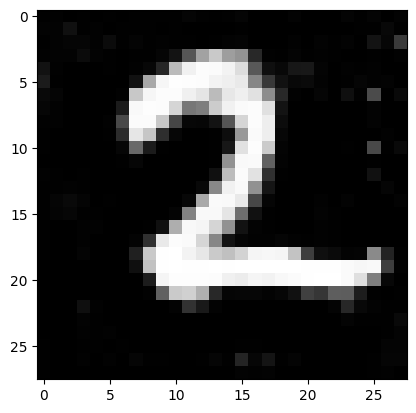

In [7]:
extra_values = tf.constant([[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])  # generate a specific class (e.g., class '2')
noise = tf.concat([tf.random.normal([1, noise_dim]), extra_values], axis=1)  # Agora shape será (1, 102)

generated_image = model(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [8]:
create_images(model, class_index_dict, images_per_class, one_hot_dict, noise_dim, output_path)

W0000 00:00:1748825273.553743   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.554065   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.554253   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.554407   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.554552   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.554699   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.554865   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.555047   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.555465   85739 gp

Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_0.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_1.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_2.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_3.png


W0000 00:00:1748825273.756918   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.757206   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.757321   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.757440   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.757565   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.757675   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.757741   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.757864   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.758015   85739 gp

Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_4.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_5.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_6.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_7.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_8.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/0/0_9.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_0.png


W0000 00:00:1748825273.958499   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.958644   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.958839   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.958964   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.959253   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.959390   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.959569   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.959738   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825273.959993   85739 gp

Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_1.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_2.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_3.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_4.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_5.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_6.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_7.png


W0000 00:00:1748825274.159705   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.160265   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.160556   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.160864   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.161050   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.161281   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.161518   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.161764   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.162300   85739 gp

Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_8.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/1/1_9.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_0.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_1.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_2.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_3.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_4.png


W0000 00:00:1748825274.376748   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.377220   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.377401   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.377606   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.377801   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.377938   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.378082   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.378268   85739 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1748825274.378472   85739 gp

Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_5.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_6.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_7.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_8.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/2/2_9.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/3/3_0.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/3/3_1.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/3/3_2.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/3/3_3.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/3/3_4.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/3/3_5.png
Saved image: /tf/data_project/output/generated_images_per_class/mnist/3/3_6.png
Saved image: /tf/data_project/output/gen